In [1]:
import jax 
import jax.numpy as jnp
from scoresbibm.src.utils.data_utils import load_model
jax.config.update("jax_platform_name", "cpu")
from scoresbibm.src.tasks.unstructured_tasks import LotkaVolterraTask

from functools import partial
from probjax.utils.odeint import _odeint
from probjax.utils.jaxutils import ravel_args
from probjax.core import joint_sample, log_potential_fn,rv, intervene
from probjax.distributions import Normal, Uniform, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.inference.mcmc import MCMC 
from probjax.inference.marcov_kernels import HMCKernel, GaussianMHKernel, SliceKernel, LangevianMHKernel


import matplotlib.pyplot as plt

In [2]:
#model = load_model("../results/benchmark/",18)

In [3]:
task = LotkaVolterraTask()

In [4]:
base_mask_fn = task.get_base_mask_fn()



In [5]:
data = task.get_data(1000, rng=jax.random.PRNGKey(0))


In [6]:
observation_generator = task.get_observation_generator()
observation_stream = observation_generator(jax.random.PRNGKey(0))

In [7]:


while True:
    condition_mask, x_o, theta_o, meta_data, node_id = next(observation_stream)
    condition_mask_wanted = jnp.array([False,False, False,False] + [True]*(len(condition_mask)-4))
    if jnp.all(condition_mask == condition_mask_wanted):
        break   

In [29]:
time_points = meta_data.shape[0] - 4

#ts1 = jnp.where(node_id == 4, meta_data, jnp.nan)[4:]
#ts2 = jnp.where(node_id == 5, meta_data, jnp.nan)[4:]

#index1 = jnp.argsort(ts1)
#index2 = jnp.argsort(ts2)
#index_x = jnp.concatenate([index1, index2 + num_timepoints1])

mask_theta = jnp.eye(4)
mask_theta_x0 = jnp.concatenate([jnp.ones((2, time_points)), jnp.zeros((2, time_points))] , axis=1)
mask_theta_x1 = jnp.concatenate([jnp.zeros((2, time_points)), jnp.ones((2, time_points))] , axis=1)
mask_theta_x = jnp.concatenate([mask_theta_x0, mask_theta_x1], axis=0)

id_mask1 = node_id[4:] == 4
id_mask2 = node_id[4:] == 5
index1 = jnp.where(id_mask1)[0]
index2 = jnp.where(id_mask2)[0]
mask_x = jnp.zeros((time_points, time_points), dtype=bool)
mask_x = mask_x.at[index2+1, index1].set(True)
mask_x = mask_x.at[index1+1, index2].set(True)
mask_x01 = jnp.tril(id_mask1[:,None] != id_mask2[None,:]) & ~jnp.tril(id_mask1[:,None] != id_mask2[None,:], k=-2)
mask_x = mask_x | mask_x01



# mask_x0 = jnp.where(id_mask1, mask_x0, False)
# mask_x1 = jnp.where(id_mask2, mask_x1, False)
# mask_x = mask_x0 | mask_x1 | mask_x0_x1 | mask_x1_x0

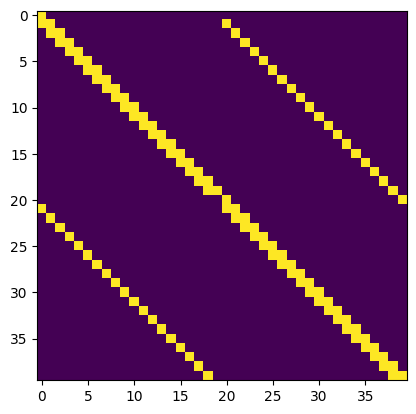

In [30]:
plt.imshow(mask_x)

In [31]:
index2

Array([20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36,
       37, 38, 39], dtype=int32)

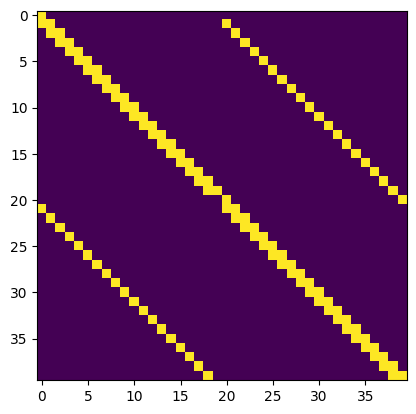

In [32]:
plt.imshow(mask_x.at[index2+1, index1].set(True))
plt.imshow(mask_x.at[index1+1, index2].set(True))

TypeError: unsupported operand type(s) for &: 'AxesImage' and 'ArrayImpl'

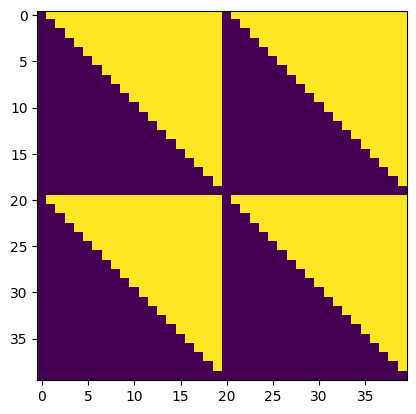

In [33]:
autoregressive = (meta_data[4:, None] > meta_data[None, 4:]) & (meta_data[4:, None] > meta_data[None, 4:])

plt.imshow(meta_data[4:, None] < meta_data[None, 4:]) & (meta_data[4:, None] < meta_data[None, 4:])

In [ ]:
plt.imshow(mask_cross_x01)

NameError: name 'mask_cross_x01' is not defined

In [8]:
base_mask_fn(node_id, meta_data)

Array([[ True, False, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False, False,  True, ...,  True, False, False],
       [False, False,  True, ...,  True,  True, False],
       [False, False,  True, ..., False,  True,  True]], dtype=bool)

In [9]:
jax.jit(base_mask_fn)(node_id, meta_data)

Array([[ True, False, False, ..., False, False, False],
       [False,  True, False, ..., False, False, False],
       [False, False,  True, ..., False, False, False],
       ...,
       [False, False,  True, ...,  True, False, False],
       [False, False,  True, ...,  True,  True, False],
       [False, False,  True, ..., False,  True,  True]], dtype=bool)

In [24]:
with jax.default_device(jax.devices("cuda")[0]):
    samples = model.sample(500, rng=jax.random.PRNGKey(0), condition_mask=condition_mask, x_o=x_o, meta_data=meta_data, node_id=node_id)

In [23]:
model_ref = task.get_reference_sampler()
samples_ref = model_ref.sample(500, rng=jax.random.PRNGKey(0), condition_mask=condition_mask, x_o=x_o, meta_data=meta_data, node_id=node_id)

dict_keys(['theta0', 'theta1', 'theta2', 'theta3']) dict_keys(['x0', 'x1'])


(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

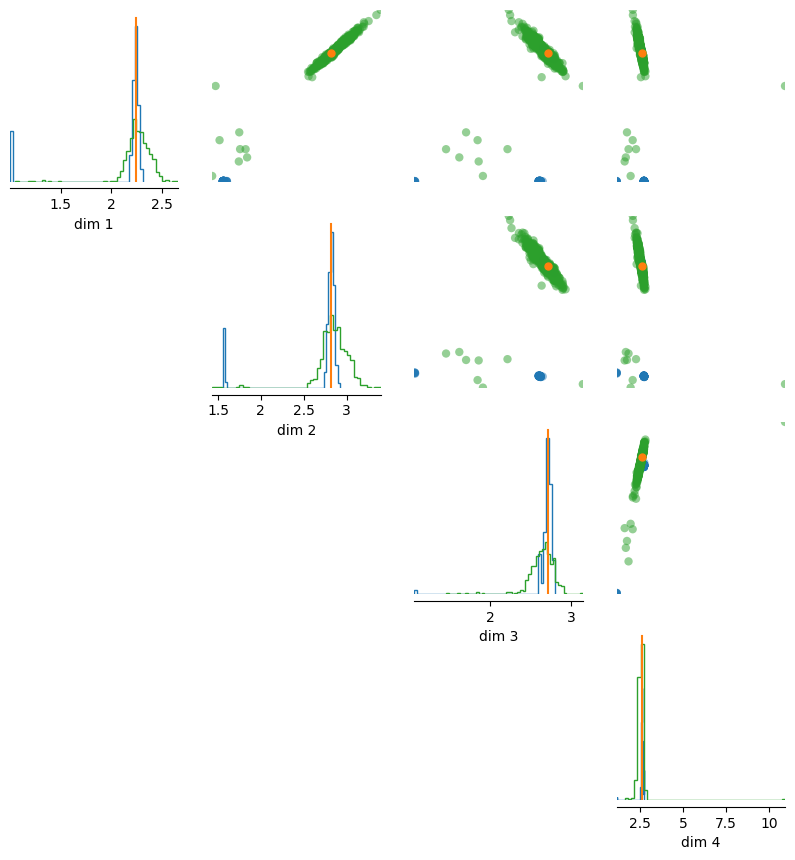

In [25]:
from sbi.analysis import pairplot
import numpy as np 

samples_ref = np.array(samples_ref)
samples = np.array(samples)
pairplot([samples_ref,samples], figsize=(10, 10), points=np.array(theta_o), upper="scatter")

In [21]:
samples = model.sample(200, rng=jax.random.PRNGKey(0), condition_mask=condition_mask, x_o=x_o, theta_o=theta_o, meta_data=meta_data)

In [28]:
meta_data.shape

(44,)

ValueError: x and y must have same first dimension, but have shapes (20,) and (4, 200)

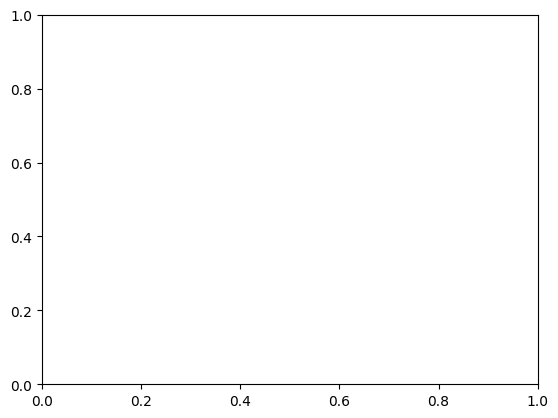

In [29]:

_ = plt.plot(meta_data[4:24],samples[:,:20].T, ".", color="C0", alpha=0.1)

In [30]:
theta_o

Array([2.244, 2.824, 2.715, 2.605], dtype=float32)

(<Figure size 1000x1000 with 4 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>]], dtype=object))

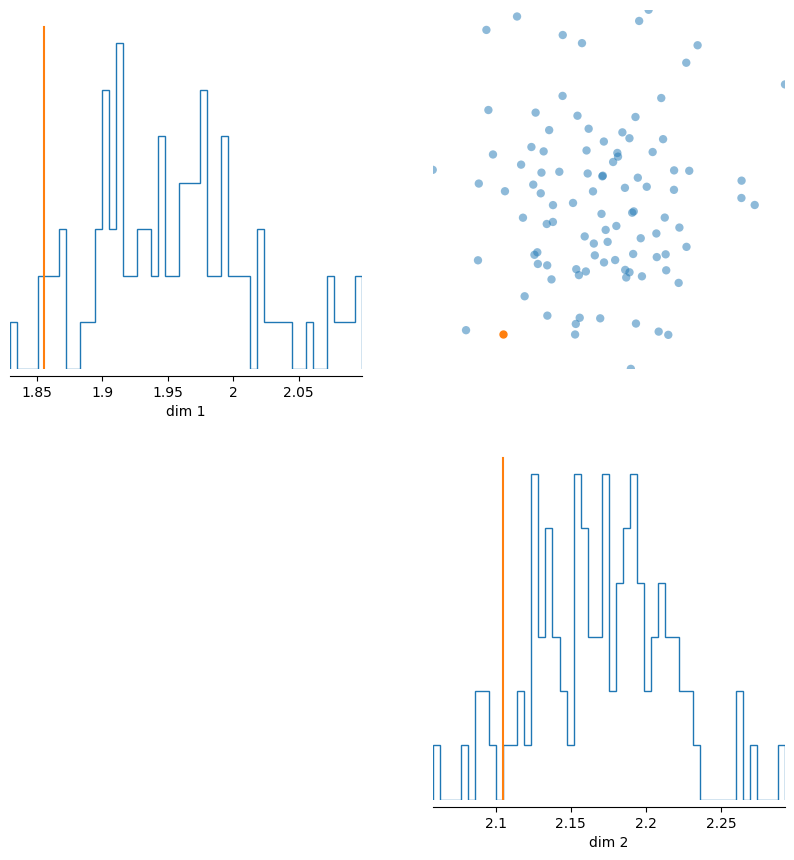

In [26]:
from sbi.analysis import pairplot
import numpy as np 

samples = np.array(samples)
pairplot(samples, figsize=(10, 10), points=np.array(theta_o), upper="scatter")

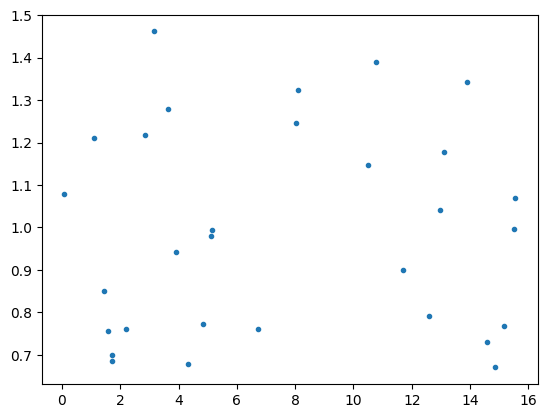

In [29]:
plt.plot(meta_data[4:34],x_o[:30], ".")